# Tối ưu hoá log-loss — Santander Product Recommendation

Bài toán: dự đoán khách hàng sẽ **thêm mới** sản phẩm nào trong tháng tới.
Mô hình hồi quy logistic $p_i=\sigma(x_i^\top w)$, $\sigma(z)=\frac{1}{1+e^{-z}}$.

**Hàm mục tiêu** — log-loss (negative log-likelihood của Bernoulli) cộng hiệu chỉnh Ridge:

$$F(w)=\underbrace{\frac1n\sum_{i=1}^n\Big[\log\big(1+e^{x_i^\top w}\big)-y_i\,x_i^\top w\Big]}_{\text{log-loss}}\;+\;\underbrace{\frac{\lambda}{2}\|w\|_2^2}_{\text{Ridge}}$$

Hàm này **lồi** và **khả vi vô hạn lần**, nên cả bốn thuật toán dưới đây đều dùng được.

## Bốn thuật toán

| Thuật toán | Giải bài toán | Vì sao dùng được |
|---|---|---|
| **GD** | Ridge | Ridge khả vi mọi nơi nên lấy gradient bình thường |
| **SGD** | Ridge | như GD nhưng gradient tính trên mini-batch |
| **Subgradient** | Lasso | L1 gãy tại 0 nên thay gradient bằng một phần tử của dưới vi phân |
| **Proximal** | Lasso | tách phần trơn (gradient) và phần gãy (toán tử prox) |

Mỗi thuật toán chạy với **độ dài bước cố định** và với **backtracking**.

**Bố cục:** dữ liệu → đặc trưng → hàm loss → 4 thuật toán → thử nhiều bước cho từng thuật toán →
so sánh 4 thuật toán → so với sklearn → chỉ số phân loại → MAP@7 → nhận xét.

In [18]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bang mau pastel, da kiem tra dat nguong phan biet cho ca nguoi mu mau
MAU = ["#4A8ACE", "#E5896A", "#AC79CE", "#1BA89A"]     # GD, SGD, AGD, Newton
NEN, LUOI, MUC, DAM = "#FCFCFB", "#E8E6E1", "#8A8781", "#2B2B2B"
plt.rcParams.update({
    "figure.facecolor": NEN, "axes.facecolor": NEN, "savefig.facecolor": NEN,
    "axes.edgecolor": "#C9C6BF", "axes.labelcolor": MUC, "axes.titlecolor": DAM,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": LUOI, "grid.linewidth": 0.8,
    "xtick.color": MUC, "ytick.color": MUC, "text.color": DAM,
    "font.size": 10, "axes.titlesize": 11.5, "axes.titlelocation": "left",
    "axes.titlepad": 10, "legend.frameon": False, "figure.dpi": 110,
})
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 120)

T0 = time.time()
def da_chay(nhan):
    print("[%5.1f phut] %s" % ((time.time() - T0) / 60, nhan))

## 1. Dữ liệu

In [ ]:
# ====================== CAU HINH ======================
SO_CAP = 1        # so cap thang dung de train; toi da 15 (= toan bo du lieu tru thang cuoi)
# ======================================================

SAN_PHAM_COLS = ["ind_ahor_fin_ult1", "ind_aval_fin_ult1", "ind_cco_fin_ult1",
    "ind_cder_fin_ult1", "ind_cno_fin_ult1", "ind_ctju_fin_ult1", "ind_ctma_fin_ult1",
    "ind_ctop_fin_ult1", "ind_ctpp_fin_ult1", "ind_deco_fin_ult1", "ind_deme_fin_ult1",
    "ind_dela_fin_ult1", "ind_ecue_fin_ult1", "ind_fond_fin_ult1", "ind_hip_fin_ult1",
    "ind_plan_fin_ult1", "ind_pres_fin_ult1", "ind_reca_fin_ult1", "ind_tjcr_fin_ult1",
    "ind_valo_fin_ult1", "ind_viv_fin_ult1", "ind_nomina_ult1", "ind_nom_pens_ult1",
    "ind_recibo_ult1"]
COT_SO = ["age", "antiguedad", "renta", "ind_nuevo", "ind_actividad_cliente", "alta_year"]
CAT = {"sexo": ["V"], "segmento": ["02 - PARTICULARES", "03 - UNIVERSITARIO"],
       "tiprel_1mes": ["I"], "canal_entrada": ["KHE", "KAT", "KFC"]}
THANG = (["2015-%02d-28" % m for m in range(1, 13)] +
         ["2016-%02d-28" % m for m in range(1, 6)])[-(SO_CAP + 2):]

# ---- doc file 2.3GB theo chunk, chi giu cac thang can, roi lam sach ----
df = pd.concat([c[c["fecha_dato"].isin(THANG)] for c in pd.read_csv("train_ver2.csv",
    usecols=["fecha_dato", "ncodpers", "fecha_alta"] + COT_SO[:-1] + list(CAT)
            + SAN_PHAM_COLS, dtype=str, chunksize=10**6)])
df[SAN_PHAM_COLS] = df[SAN_PHAM_COLS].apply(pd.to_numeric, errors="coerce").fillna(0)
for c, lo, hi in [("age", 18, 95), ("antiguedad", 0, 260),      # -999999 = thieu -> 0
                  ("ind_nuevo", 0, 1), ("ind_actividad_cliente", 0, 1)]:
    df[c] = pd.to_numeric(df[c], errors="coerce").clip(lo, hi)
df["renta"] = np.log1p(pd.to_numeric(df["renta"], errors="coerce").clip(0, 1.5e6))
df["alta_year"] = pd.to_datetime(df["fecha_alta"], errors="coerce").dt.year
df[COT_SO] = df[COT_SO].astype(float).fillna(df[COT_SO].astype(float).median())

# ---- ghep cap thang (t-1, t) -> X va nhan "them moi" ----
def tao(lag, dich):
    lag_ten = [c + "_lag" for c in SAN_PHAM_COLS]
    m = df[df["fecha_dato"] == dich].merge(
        df[df["fecha_dato"] == lag][["ncodpers"] + SAN_PHAM_COLS]
          .set_axis(["ncodpers"] + lag_ten, axis=1), on="ncodpers")
    Y = (m[SAN_PHAM_COLS].values == 1) & (m[lag_ten].values == 0)   # co o t, khong co o t-1
    X = np.hstack([m[COT_SO].values,
                   np.column_stack([(m[c] == v).values for c, vs in CAT.items() for v in vs]),
                   m[lag_ten].values])
    return X.astype(float), Y.astype(np.int8)

Xs, Ys = zip(*[tao(THANG[i], THANG[i + 1]) for i in range(len(THANG) - 2)])
X_tr, Y_tr = np.vstack(Xs), np.vstack(Ys)
X_va, Y_va = tao(THANG[-2], THANG[-1])                # cap cuoi lam validation

mu, sd = X_tr.mean(0), X_tr.std(0)
sd[sd < 1e-8] = 1.0
X_tr = np.c_[np.ones(len(X_tr)), (X_tr - mu) / sd]    # cot 0 = intercept, khong bi phat
X_va = np.c_[np.ones(len(X_va)), (X_va - mu) / sd]

ten_cot = (["intercept"] + COT_SO + ["%s=%s" % (c, v) for c, vs in CAT.items() for v in vs]
           + [c + "_lag" for c in SAN_PHAM_COLS])
k = SAN_PHAM_COLS.index("ind_recibo_ult1")            # san pham co ti le mua cao nhat
y_tr, y_va = Y_tr[:, k].astype(float), Y_va[:, k].astype(float)
n, d = X_tr.shape
THANG_DU_BAO, ten_dep = THANG[-1], lambda t: t
print("X_tr:", X_tr.shape, "| X_va:", X_va.shape,
      "| ti le duong: train %.3f%% valid %.3f%%" % (y_tr.mean()*100, y_va.mean()*100))
pd.DataFrame(np.vstack(Xs), columns=ten_cot[1:]).describe().T.round(3)   # thong ke mo ta

## 2. Bộ đặc trưng — liệt kê đầy đủ và công thức

Ký hiệu: $\mathbb{1}[\cdot]$ là hàm chỉ báo; $\mathrm{clip}(x,a,b)=\min(\max(x,a),b)$.

| # | Cột | Công thức | Nghĩa cột gốc (tiếng Tây Ban Nha) |
|---|---|---|---|
| 0 | `intercept` | $1$ | hệ số chặn, **không bị phạt** |
| 1 | `age` | $\mathrm{clip}(\text{age},18,95)$ | tuổi (dữ liệu có giá trị 2 và 164 → lỗi nhập) |
| 2 | `antiguedad` | $\mathrm{clip}(\cdot,0,260)$, mã $-999999\to$NaN | thâm niên khách hàng, tính bằng **tháng** |
| 3 | `renta` | $\log(1+\mathrm{clip}(\cdot,0,1{,}5{\times}10^6))$ | thu nhập hộ gia đình (EUR/năm) |
| 4 | `ind_nuevo` | giữ nguyên $\{0,1\}$ | khách mới (đăng ký < 6 tháng) |
| 5 | `ind_actividad_cliente` | giữ nguyên $\{0,1\}$ | khách đang hoạt động |
| 6 | `alta_year` | $\mathrm{year}(\text{fecha\_alta})$ | năm trở thành khách hàng |
| 7 | `sexo=V` | $\mathbb{1}[\text{sexo}=\texttt{V}]$ | `V` = varón (nam), `H` = hembra (nữ) |
| 8–9 | `segmento=…` | $\mathbb{1}[\cdot]$ | `01-TOP` (VIP), `02-PARTICULARES` (cá nhân), `03-UNIVERSITARIO` (sinh viên) |
| 10 | `tiprel_1mes=I` | $\mathbb{1}[\cdot]$ | quan hệ đầu tháng: `A` active, `I` inactive, `P` former, `R` potential |
| 11–13 | `canal_entrada=…` | $\mathbb{1}[\cdot]$, top-3 kênh | kênh khách vào ngân hàng (mã nội bộ) |
| 14–37 | `ind_*_ult1_lag` | $\mathbb{1}[\text{sở hữu sản phẩm }k\text{ ở }t-1]$ | **24 cờ sở hữu tháng trước** |

**Giá trị thiếu**: cột số điền **trung vị**; cột hạng mục điền `"NA"` thành một mức riêng.

**Chuẩn hoá** (mọi cột trừ intercept), thống kê lấy từ **tập train**:
$x_{ij}\leftarrow(x_{ij}-\mu_j)/\sigma_j$. Bắt buộc phải làm, vì (i) đưa mọi cột về cùng
thang đo nên $\lambda$ phạt công bằng, (ii) ma trận điều kiện tốt hơn nhiều → GD/SGD hội
tụ nhanh hơn hẳn.


## 3. Hàm mục tiêu và gradient

$$F(w)=\frac1n\sum_i\big[\log(1+e^{z_i})-y_iz_i\big]+\frac{\lambda}{2}\|w\|^2,\qquad z=Xw$$

$$\nabla F(w)=\frac1nX^\top\big(\sigma(Xw)-y\big)+\lambda_2 w$$

Dạng $\log(1+e^{z})-yz$ **chính là** $-[y\log p+(1-y)\log(1-p)]$ sau khi rút gọn (dấu âm
đã nằm trong số hạng $-yz$), nhưng ổn định số hơn hẳn: dùng `np.logaddexp(0, z)` thì
không bao giờ tràn, còn `log(p)` với $p$ cực nhỏ sẽ ra `-inf`.

**Hằng số Lipschitz.** Vì $\sigma'(z)\le\frac14$ nên $\nabla F$ Lipschitz với
$L=\frac{\sigma_{\max}(X)^2}{4n}+\lambda$; bước $t=1/L$ **luôn** đảm bảo GD hội tụ.

In [ ]:
def sigmoid(z):
    out = np.zeros_like(z, dtype=float)
    duong = z >= 0                                # tach 2 nhanh cho khoi tran so
    out[duong] = 1 / (1 + np.exp(-z[duong]))
    e = np.exp(z[~duong])
    out[~duong] = e / (1 + e)
    return out


def logloss(w, X, y, lam2=0.0, lam1=0.0):

    z = X @ w
    F = np.mean(np.logaddexp(0, z) - y * z)
    if lam2 > 0:
        F = F + 0.5 * lam2 * np.sum(w[1:] ** 2)          # Ridge
    if lam1 > 0:
        F = F + lam1 * np.sum(np.abs(w[1:]))             # Lasso
    return F


def grad(w, X, y, lam2=0.0):
    '''Gradient cua phan TRON (log-loss + Ridge). Lasso khong co gradient.'''
    g = X.T @ (sigmoid(X @ w) - y) / X.shape[0]
    g[1:] += lam2 * w[1:]
    return g

In [25]:
# Kiem tra gradient bang sai phan huu han - phai lam TRUOC khi chay thuat toan
LAM2 = LAM1 = 1e-3               # lam2 = Ridge, lam1 = Lasso
VONG = 40                        # ngan sach chung: 40 vong lap
w_thu = np.random.RandomState(0).randn(d) * 0.05
g = grad(w_thu, X_tr, y_tr, LAM2)
sai_so = 0.0
for j in np.random.RandomState(0).choice(d, 10, replace=False):
    w1, w2 = w_thu.copy(), w_thu.copy()
    w1[j] += 1e-6; w2[j] -= 1e-6
    sp = (logloss(w1, X_tr, y_tr, LAM2) - logloss(w2, X_tr, y_tr, LAM2)) / 2e-6
    sai_so = max(sai_so, abs(sp - g[j]))
print("sai so gradient:", sai_so, " (phai ~1e-9)")

# Hang so Lipschitz bang power iteration
v = np.random.RandomState(0).rand(d); v /= np.linalg.norm(v)
for _ in range(50):
    v = X_tr.T @ (X_tr @ v); v /= np.linalg.norm(v)
L = np.sum((X_tr @ v) ** 2) / (4 * n) + LAM2
eta = 1 / L
print("L = %.4f -> buoc an toan 1/L = %.4f" % (L, eta))

p0 = y_tr.mean()
MOC = -(p0 * np.log(p0) + (1 - p0) * np.log(1 - p0))
print("MOC: log-loss cua mo hinh hang so = %.6f" % MOC)

sai so gradient: 3.214563372433421e-10  (phai ~1e-9)
L = 1.4596 -> buoc an toan 1/L = 0.6851
MOC: log-loss cua mo hinh hang so = 0.058794


## 4. Bốn thuật toán

Mỗi thuật toán là **một hàm tự chứa, đọc thẳng từ trên xuống**, chỉ dùng chung ba hàm mô
tả *bài toán* ở trên (`sigmoid`, `logloss`, `grad`). Tất cả trả về `w` và `ls` — lịch sử
$F$, thời gian, số hệ số khác 0, log-loss validation sau mỗi vòng lặp.

Quy ước: `buoc` là số → **độ dài bước cố định**; `buoc=None` → **backtracking**.

| Hàm | Giải | Cập nhật |
|---|---|---|
| `gradient_descent` | Ridge | $w\leftarrow w-t\nabla F$ |
| `sgd` | Ridge | như GD nhưng gradient trên mini-batch |
| `subgradient` | Lasso | thay $\nabla$ bằng một phần tử của $\partial F$ |
| `proximal` | Lasso | gradient cho phần trơn + `prox` cho phần gãy |

In [ ]:
def gradient_descent(X, y, lam2=0.0, buoc=None, so_vong=40):
    n, d = X.shape
    w = np.zeros(d)
    t = 1.0 if buoc is None else buoc
    ls = {"F": [], "time": [], "nnz": [], "val": []}
    t0 = time.time()

    for k in range(so_vong):
        g = X.T @ (sigmoid(X @ w) - y) / n
        g[1:] += lam2 * w[1:]

        if buoc is None:
            F0, chuan = logloss(w, X, y, lam2), np.sum(g ** 2)
            t = t * 2
            for _ in range(50):
                if logloss(w - t * g, X, y, lam2) <= F0 - 1e-4 * t * chuan:
                    break
                t = t / 2
        w = w - t * g

        ls["F"].append(logloss(w, X, y, lam2))
        ls["time"].append(time.time() - t0)
        ls["nnz"].append(int(np.sum(w != 0)))
        ls["val"].append(logloss(w, X_va, y_va))
    return w, ls

def backtracking_gradient_descent(X, y, lam2=0.0, so_vong=40):
    return gradient_descent(X, y, lam2, buoc=None, so_vong=so_vong)

def fixed_step_gradient_descent(X, y, lam2=0.0, buoc=1e-3, so_vong=40):
    return gradient_descent(X, y, lam2, buoc=buoc, so_vong=so_vong)


backtracking_gradient_descent(X_tr, y_tr, lam2=LAM2, so_vong=VONG)

In [27]:
def sgd(X, y, lam2=0.0, batch=1024, so_vong=40, eta0=0.5, kieu_buoc="1/k",
        momentum=0.0, seed=0):
    '''
    SGD MINI-BATCH:  w = w - eta_k * grad_B(w)
    grad_B tinh tren batch ngau nhien -> moi buoc re hon n/batch lan nhung co nhieu,
    nen buoc phai giam dan (dieu kien Robbins-Monro).
    kieu_buoc: "hang_so" | "1/k" (eta0/(1+1e-3 k)) | "1/sqrt(k)"
    '''
    n, d = X.shape
    rs = np.random.RandomState(seed)
    w = np.zeros(d)
    v = np.zeros(d)
    ls = {"F": [], "time": [], "nnz": [], "val": []}
    t0 = time.time()

    k = 0
    for epoch in range(so_vong):
        thu_tu = rs.permutation(n)                       # xao tron moi epoch
        for i in range(0, n, batch):
            idx = thu_tu[i:i + batch]
            Xb, yb = X[idx], y[idx]
            g = Xb.T @ (sigmoid(Xb @ w) - yb) / len(idx)
            g[1:] += lam2 * w[1:]

            if kieu_buoc == "hang_so":     eta = eta0
            elif kieu_buoc == "1/k":       eta = eta0 / (1 + 1e-3 * k)
            elif kieu_buoc == "1/sqrt(k)": eta = eta0 / np.sqrt(1 + k)

            if momentum > 0:
                v = momentum * v + g
                w = w - eta * v
            else:
                w = w - eta * g
            k += 1

        ls["F"].append(logloss(w, X, y, lam2))
        ls["time"].append(time.time() - t0)
        ls["nnz"].append(int(np.sum(w != 0)))
        ls["val"].append(logloss(w, X_va, y_va))
    return w, ls

In [28]:
def subgradient(X, y, lam1=1e-3, eta0=0.5, so_vong=40, kieu_buoc="1/sqrt(k)",
                cach_chon="min_norm", seed=0):
    '''
    LASSO bang PHUONG PHAP DUOI DAO HAM:  w = w - eta_k * g,  g thuoc dF(w)

    Tai w_j = 0 duoi vi phan la CA DOAN [-lam1, lam1] nen phai CHON mot phan tu:
      "min_norm" -> phan tu chuan nho nhat: g_j = grad_j - clip(grad_j, -lam1, lam1)
      "random"   -> lay ngau nhien trong doan
    F KHONG giam don dieu nen phai nho lai nghiem tot nhat da gap.
    '''
    n, d = X.shape
    rs = np.random.RandomState(seed)
    w = np.zeros(d)
    w_tot, F_tot = w.copy(), logloss(w, X, y, 0.0, lam1)
    ls = {"F": [], "time": [], "nnz": [], "val": []}
    t0 = time.time()

    for k in range(1, so_vong + 1):
        g = X.T @ (sigmoid(X @ w) - y) / n
        khac_0 = w != 0;  khac_0[0] = False              # bo intercept
        bang_0 = w == 0;  bang_0[0] = False
        g[khac_0] += lam1 * np.sign(w[khac_0])           # w_j != 0: dao ham duy nhat
        if cach_chon == "min_norm":                      # w_j = 0: phai CHON
            g[bang_0] -= np.clip(g[bang_0], -lam1, lam1)
        else:
            g[bang_0] += rs.uniform(-lam1, lam1, bang_0.sum())

        if kieu_buoc == "hang_so":     eta = eta0
        elif kieu_buoc == "1/k":       eta = eta0 / (1 + k)
        elif kieu_buoc == "1/sqrt(k)": eta = eta0 / np.sqrt(1 + k)
        w = w - eta * g

        F = logloss(w, X, y, 0.0, lam1)
        if F < F_tot:                                    # nho nghiem tot nhat
            F_tot, w_tot = F, w.copy()
        ls["F"].append(F)
        ls["time"].append(time.time() - t0)
        ls["nnz"].append(int(np.sum(w != 0)))
        ls["val"].append(logloss(w, X_va, y_va))
    return w_tot, ls

In [ ]:
def proximal(X, y, lam1=1e-3, buoc=None, so_vong=40, gia_toc=True):
    '''
    LASSO bang PROXIMAL GRADIENT:
        w = prox( w - t*grad(w) ),   prox = soft-thresholding
        soft(u, a) = sign(u) * max(|u| - a, 0)    <- dat HAN he so nho ve 0

    gia_toc=True -> FISTA, them ngoai suy Nesterov:
        v = w_k + (k-1)/(k+2)*(w_k - w_{k-1});  w = prox( v - t*grad(v) )
        Toc do: ISTA O(1/k) -> FISTA O(1/k^2), chi phi moi vong y het nhau.
    buoc=None -> backtracking tren dieu kien du giam.
    '''
    n, d = X.shape
    w = np.zeros(d)
    w_truoc = np.zeros(d)
    t = 1.0 if buoc is None else buoc
    ls = {"F": [], "time": [], "val": []}
    t0 = time.time()

    for k in range(1, so_vong + 1):
        v = w + (k - 1) / (k + 2) * (w - w_truoc) if gia_toc else w
        g = X.T @ (sigmoid(X @ v) - y) / n

        if buoc is None:
            Fv = logloss(v, X, y)
            t = t * 1.5                                  # thu buoc lon hon truoc
            for _ in range(50):
                u = v - t * g
                u[1:] = np.sign(u[1:]) * np.maximum(np.abs(u[1:]) - t * lam1, 0)
                hieu = u - v
                if logloss(u, X, y) <= Fv + g @ hieu + hieu @ hieu / (2 * t):
                    break
                t = t / 2
        else:
            u = v - t * g
            u[1:] = np.sign(u[1:]) * np.maximum(np.abs(u[1:]) - t * lam1, 0)

        w_truoc, w = w, u

        ls["F"].append(logloss(w, X, y, 0.0, lam1))
        ls["time"].append(time.time() - t0)
        ls["val"].append(logloss(w, X_va, y_va))
    return w, ls

## 5. Với mỗi thuật toán: thử nhiều độ dài bước, chọn cái xuống đáy thấp nhất

Cách làm cho **từng** thuật toán:

1. chạy nhiều cấu hình khác nhau, **cùng ngân sách 40 vòng lặp**, cùng $\lambda=10^{-3}$;
2. vẽ tất cả lên một hình — trục tung là $F(w)$, trục hoành là số vòng lặp;
3. đường nào **xuống đáy thấp nhất** thì đó là setup tốt nhất của thuật toán đó;
4. rút ra kinh nghiệm chọn tham số.

Giữ $\lambda$ **cố định** trong toàn mục này là cố ý: đổi $\lambda$ là đổi luôn hàm mục
tiêu, lúc đó $F$ của hai cấu hình không so được với nhau nữa. Việc chọn $\lambda$ để riêng
ở mục 8.

Màu trong các hình dưới đi theo **thang đậm dần** vì độ dài bước là đại lượng **có thứ
tự**: bước càng lớn màu càng đậm. Riêng backtracking không nằm trên thang đó nên dùng màu
cam khác hẳn.

In [ ]:

THANG = ["#9EC5F4", "#6DA7EC", "#3987E5", "#256ABF", "#104281", "#0D366B"]
MAU_BT = "#E5896A"

def thu_nhieu_cau_hinh(ten, luoi, chay, lam1=0.0, lam2=0.0):
    '''
    Chay het luoi cau hinh, ve F theo so vong lap, in bang, tra ve cau hinh
    co F CUOI CUNG THAP NHAT ("cai day").
    '''
    ket = []
    for cfg, ts in luoi:
        w, ls = chay(ts)
        ket.append([cfg, w, ls, ts])

    plt.figure(figsize=(8.2, 4.8))
    for i, (cfg, w, ls, ts) in enumerate(ket):
        la_bt = ts.get("buoc", 1) is None
        mau = MAU_BT if la_bt else THANG[min(i, len(THANG) - 1)]
        plt.plot(np.arange(1, len(ls["F"]) + 1), ls["F"], color=mau,
                 lw=2.6 if la_bt else 2.0, ls="--" if la_bt else "-", label=cfg)
    F_day = min(ls["F"][-1] for _, _, ls, _ in ket)
    plt.axhline(F_day, color=MUC, ls=":", lw=1)
    plt.text(0.99, F_day, " day: F = %.6f" % F_day, color=MUC, fontsize=8,
             ha="right", va="bottom", transform=plt.gca().get_yaxis_transform())
    plt.yscale("log")
    plt.xlabel("so vong lap (iterations)")
    plt.ylabel("gia tri ham muc tieu  F(w)")
    plt.title("%s - thu %d do dai buoc khac nhau" % (ten, len(luoi)))
    plt.legend(fontsize=8.5, loc="upper right")
    plt.tight_layout(); plt.show()

    ket.sort(key=lambda r: r[2]["F"][-1] if np.isfinite(r[2]["F"][-1]) else np.inf)
    print("%-30s%15s%14s%7s%8s" % ("cau hinh", "F cuoi", "log-loss va", "nnz", "giay"))
    print("-" * 76)
    for cfg, w, ls, ts in ket:
        F = ls["F"][-1]
        print("%-30s%15s%14.6f%7d%8.1f"
              % (cfg, "%.8f" % F if np.isfinite(F) else "phan ky",
                 ls["val"][-1], ls["nnz"][-1], ls["time"][-1]))
    print("\n=> TOT NHAT: %s" % ket[0][0])
    return ket[0]

### 5.1 Gradient Descent

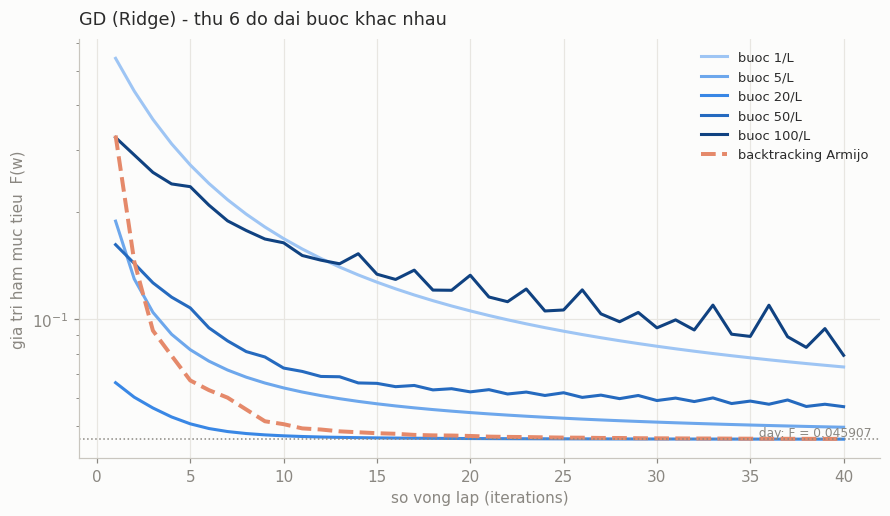

cau hinh                               F cuoi   log-loss va    nnz    giay
----------------------------------------------------------------------------
buoc 20/L                          0.04590703      0.045056     38     4.2
backtracking Armijo                0.04598297      0.045449     38     7.3
buoc 5/L                           0.04959452      0.050046     38     4.1
buoc 50/L                          0.05667621      0.047738     38     4.1
buoc 1/L                           0.07332192      0.074076     38     4.2
buoc 100/L                         0.07907208      0.052421     38     4.0

=> TOT NHAT: buoc 20/L
[  0.6 phut] xong GD


In [32]:
tot_gd = thu_nhieu_cau_hinh("GD (Ridge)",
    [("buoc %g/L" % c, {"buoc": eta * c}) for c in (1, 5, 20, 50, 100)] +
    [("backtracking Armijo", {"buoc": None})],
    lambda ts: gradient_descent(X_tr, y_tr, LAM2, so_vong=VONG, **ts))
da_chay("xong GD")

**Kinh nghiệm rút ra cho GD.** Bước $1/L$ là bước *an toàn* suy từ chặn Lipschitz cho
trường hợp xấu nhất — trên dữ liệu thật nó **quá bi quan**, đi rất chậm. Tăng bước lên
hàng chục lần vẫn hội tụ và nhanh hơn hẳn, cho tới khi quá lớn thì bắt đầu dao động/phân
kỳ. **Backtracking** tránh được toàn bộ việc dò tay này: mỗi vòng nó tự thử bước lớn rồi
co lại đến khi thoả điều kiện Armijo, nên gần như luôn nằm trong nhóm tốt nhất mà không
cần biết $L$.

### 5.2 SGD

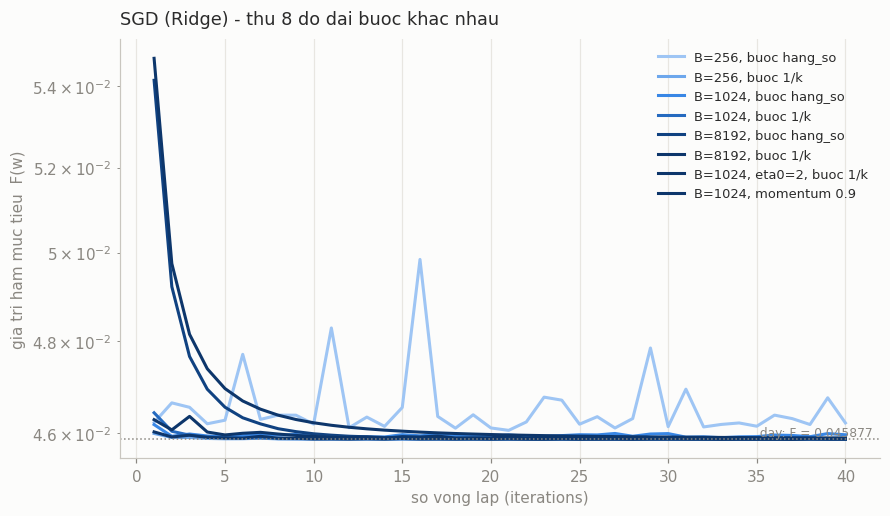

cau hinh                               F cuoi   log-loss va    nnz    giay
----------------------------------------------------------------------------
B=256, buoc 1/k                    0.04587665      0.045020     38    40.5
B=1024, buoc 1/k                   0.04587692      0.045034     38    22.5
B=1024, eta0=2, buoc 1/k           0.04587771      0.045008     38    22.6
B=8192, buoc hang_so               0.04588143      0.045004     38    19.9
B=1024, momentum 0.9               0.04589370      0.044995     38    30.5
B=8192, buoc 1/k                   0.04590146      0.045194     38    20.1
B=1024, buoc hang_so               0.04596935      0.044987     38    23.4
B=256, buoc hang_so                0.04622116      0.045105     38    39.9

=> TOT NHAT: B=256, buoc 1/k
[  4.3 phut] xong SGD


In [33]:
tot_sgd = thu_nhieu_cau_hinh("SGD (Ridge)",
    [("B=%d, buoc %s" % (b, kb), {"batch": b, "eta0": eta, "kieu_buoc": kb})
     for b in (256, 1024, 8192) for kb in ("hang_so", "1/k")] +
    [("B=1024, eta0=2, buoc 1/k", {"batch": 1024, "eta0": 2.0, "kieu_buoc": "1/k"}),
     ("B=1024, momentum 0.9", {"batch": 1024, "eta0": eta, "kieu_buoc": "1/k",
                               "momentum": 0.9})],
    lambda ts: sgd(X_tr, y_tr, LAM2, so_vong=VONG, **ts))
da_chay("xong SGD")

**Kinh nghiệm rút ra cho SGD.** Batch càng **nhỏ** thì mỗi lần duyệt dữ liệu càng nhiều
bước cập nhật ($n/B$ bước), nên tiến nhanh hơn tính theo số epoch — nhưng nhiễu hơn và
tốn nhiều thời gian thực hơn vì gọi nhiều phép nhân ma trận nhỏ. Batch quá lớn (8192) thì
mỗi epoch chỉ đi được ít bước, hoá ra chậm. Lịch bước giảm dần $\eta_0/(1+\gamma k)$ ổn
định hơn bước hằng ở cuối, vì gần nghiệm thì nhiễu của gradient ngẫu nhiên mới là thứ chi
phối.

### 5.3 Subgradient

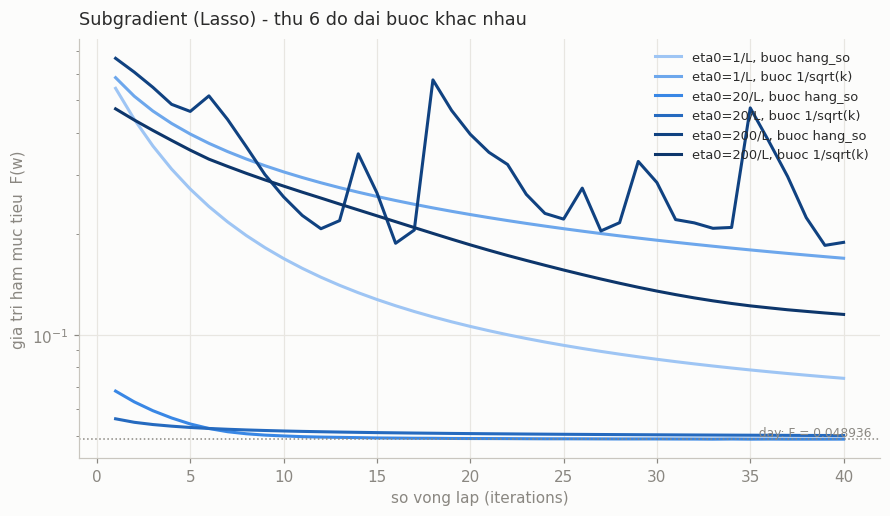

cau hinh                               F cuoi   log-loss va    nnz    giay
----------------------------------------------------------------------------
eta0=20/L, buoc hang_so            0.04893607      0.045896     26     5.6
eta0=20/L, buoc 1/sqrt(k)          0.05014852      0.048788     25     5.8
eta0=1/L, buoc hang_so             0.07426328      0.074613     25     5.8
eta0=200/L, buoc 1/sqrt(k)         0.11510841      0.075557     27     5.0
eta0=1/L, buoc 1/sqrt(k)           0.16923350      0.169562     25     5.7
eta0=200/L, buoc hang_so           0.18870624      0.141022     36     5.7

=> TOT NHAT: eta0=20/L, buoc hang_so
[  4.9 phut] xong Subgradient


In [34]:
tot_sub = thu_nhieu_cau_hinh("Subgradient (Lasso)",
    [("eta0=%g/L, buoc %s" % (c, kb), {"eta0": eta * c, "kieu_buoc": kb})
     for c in (1, 20, 200) for kb in ("hang_so", "1/sqrt(k)")],
    lambda ts: subgradient(X_tr, y_tr, LAM1, so_vong=VONG, **ts))
da_chay("xong Subgradient")

**Kinh nghiệm rút ra cho Subgradient.** Đây là thuật toán **nhạy tham số nhất** trong bốn
cái. Lý thuyết đòi bước **giảm dần** ($\sum\eta_k=\infty$, $\sum\eta_k^2<\infty$); bước
hằng chỉ đưa nghiệm tới một **lân cận** của $w^\star$ rồi dao động quanh đó — nhìn trên đồ
thị là đường đi ngang chứ không xuống nữa. Ngoài ra $F$ **không giảm đơn điệu**, nên bắt
buộc phải nhớ lại nghiệm tốt nhất đã gặp thay vì lấy $w$ ở vòng cuối.

### 5.4 Proximal

In [ ]:
tot_prox = thu_nhieu_cau_hinh("Proximal (Lasso)",
    [("%s, buoc %g/L" % (tg, c), {"gia_toc": g, "buoc": eta * c})
     for g, tg in ((False, "ISTA"), (True, "FISTA")) for c in (1, 20)] +
    [("%s, backtracking" % tg, {"gia_toc": g, "buoc": None})
     for g, tg in ((False, "ISTA"), (True, "FISTA"))],
    lambda ts: proximal(X_tr, y_tr, LAM1, so_vong=VONG, **ts))
da_chay("xong Proximal")

**Kinh nghiệm rút ra cho Proximal.** Chỉ cần bật **gia tốc Nesterov** (FISTA) là tốc độ
nhảy từ $O(1/k)$ lên $O(1/k^2)$ mà **chi phí mỗi vòng y hệt** — gần như là bữa trưa miễn
phí, luôn nên bật. Kết hợp thêm backtracking thì không cần biết $L$. Đáng chú ý: FISTA
không giảm đơn điệu (đường có gợn sóng nhẹ) — đó là bản chất của gia tốc, không phải lỗi.

## 6. So sánh bốn thuật toán ở setup tốt nhất

Mỗi thuật toán lấy **cấu hình đã chọn ở mục 5**, vẽ trên cùng hệ trục. Theo yêu cầu, vẽ
**hai hình riêng**: một theo số vòng lặp, một theo thời gian chạy thực tế.

> **Đọc cho đúng:** GD/SGD tối ưu $F=\ell+\frac{\lambda}{2}\|w\|_2^2$ (Ridge), còn
> Subgradient/Proximal tối ưu $F=\ell+\lambda\|w\|_1$ (Lasso) — **hai hàm mục tiêu khác
> nhau**, nên chỉ so trong cùng nhóm. Hai đường ngang đứt nét là $F^\star$ của từng bài
> toán. Cột `log-loss va` trong bảng là log-loss **trần** nên so chéo được cả bốn.

In [ ]:
def auc(y, p):
    '''AUC = xac suat mau duong duoc xep hang cao hon mau am.'''
    hang = np.empty(len(p))
    hang[np.argsort(p)] = np.arange(1, len(p) + 1)
    nd, na = y.sum(), len(y) - y.sum()
    return (hang[y == 1].sum() - nd * (nd + 1) / 2) / (nd * na)

TEN_4 = ["GD", "SGD", "Subgradient", "Proximal"]
BAI_TOAN = ["Ridge", "Ridge", "Lasso", "Lasso"]
tot = [tot_gd, tot_sgd, tot_sub, tot_prox]

# F* tham chieu: chay that lau
w_ref_r, _ = gradient_descent(X_tr, y_tr, LAM2, buoc=None, so_vong=300)
w_ref_l, _ = proximal(X_tr, y_tr, LAM1, buoc=None, so_vong=300, gia_toc=True)
F_SAO_RIDGE = logloss(w_ref_r, X_tr, y_tr, LAM2)
F_SAO_LASSO = logloss(w_ref_l, X_tr, y_tr, 0.0, LAM1)
print("F* Ridge = %.10f | F* Lasso = %.10f" % (F_SAO_RIDGE, F_SAO_LASSO))

print("\n%-14s%-9s%-28s%14s%13s%8s%6s%8s" %
      ("thuat toan", "bai toan", "cau hinh tot nhat", "F cuoi", "log-loss va",
       "AUC", "nnz", "giay"))
print("-" * 102)
for i in range(4):
    cfg, w, ls, ts = tot[i]
    print("%-14s%-9s%-28s%14.8f%13.6f%8.4f%6d%8.1f"
          % (TEN_4[i], BAI_TOAN[i], cfg, ls["F"][-1], ls["val"][-1],
             auc(y_va, sigmoid(X_va @ w)), ls["nnz"][-1], ls["time"][-1]))

In [ ]:
def ve_so_sanh(truc, tieu_de):
    '''truc = "vong" -> truc hoanh la so vong lap; "time" -> la giay.'''
    plt.figure(figsize=(8.2, 4.8))
    for i in range(4):
        ls = tot[i][2]
        x = np.arange(1, len(ls["F"]) + 1) if truc == "vong" else ls["time"]
        plt.plot(x, ls["F"], color=MAU[i], lw=2.4,
                 label="%s (%s)" % (TEN_4[i], tot[i][0]))
    for F_sao, ten_sao in [(F_SAO_RIDGE, "F* Ridge"), (F_SAO_LASSO, "F* Lasso")]:
        plt.axhline(F_sao, color=MUC, ls="--", lw=1)
        plt.text(0.99, F_sao, ten_sao, color=MUC, fontsize=8, ha="right", va="bottom",
                 transform=plt.gca().get_yaxis_transform())
    plt.yscale("log")
    plt.xlabel("so vong lap (iterations)" if truc == "vong" else "thoi gian chay (giay)")
    plt.ylabel("gia tri ham muc tieu  F(w)")
    plt.title(tieu_de)
    plt.legend(fontsize=8.5)
    plt.tight_layout(); plt.show()

ve_so_sanh("vong", "So sanh 4 thuat toan - F theo SO VONG LAP")
ve_so_sanh("time", "So sanh 4 thuat toan - F theo THOI GIAN CHAY")

### Kết luận của phần so sánh

- **Theo số vòng lặp**: SGD tiến nhanh nhất ở giai đoạn đầu vì mỗi lần duyệt dữ liệu nó
  cập nhật $n/B$ lần chứ không phải 1 lần như GD.
- **Theo thời gian thực**: thứ hạng **đảo lại**. SGD gọi $n/B$ phép nhân ma trận **nhỏ**
  mỗi epoch, còn GD/Proximal chỉ gọi **một** phép nhân lớn — BLAS chạy phép lớn hiệu quả
  hơn nhiều khi số cột nhỏ. Đây chính là lý do đề bài bắt vẽ hai hình riêng.
- **Trong nhóm Lasso**: Proximal (FISTA) bỏ xa Subgradient, đúng như lý thuyết
  $O(1/k^2)$ so với $O(1/\sqrt k)$.

## 7. So sánh với `sklearn` — giá trị hàm mục tiêu và thời gian

Phép thử "code tự viết có bằng thư viện không". So **giá trị hàm mục tiêu** và **thời
gian**, không phải độ chính xác.

**Chi tiết phải xử lý cho đúng.** `sklearn` tối thiểu hoá

$$\tfrac12\|w\|_2^2+C\sum_{i=1}^n\ell_i(w)\qquad\text{(tổng)}$$

còn ta dùng **trung bình**. Chia hai vế cho $Cn$ được $\frac{1}{2Cn}\|w\|^2+\frac1n\sum_i\ell_i$,
tức $\lambda^{\text{sklearn}}=\frac{1}{Cn}$. Nên `sklearn` mặc định ($C=1$) **không** giải
cùng bài toán với ta. Báo cáo cả hai kịch bản: **(a)** sklearn mặc định hoàn toàn,
**(b)** sklearn chỉnh $C=\frac{1}{\lambda n}$ để giải **đúng cùng bài toán** — chỉ (b) mới
so $F$ sòng phẳng.

In [ ]:
from sklearn.linear_model import LogisticRegression

Xs_tr = X_tr[:, 1:]                          # sklearn tu them intercept

# ---- (b) CUNG BAI TOAN RIDGE ----
C_khop = 1.0 / (LAM2 * n)
t0 = time.time()
sk_l2 = LogisticRegression(C=C_khop, max_iter=1000).fit(Xs_tr, y_tr)
t_sk_l2 = time.time() - t0
w_sk_l2 = np.concatenate([sk_l2.intercept_, sk_l2.coef_.ravel()])

print("(b) CUNG BAI TOAN RIDGE (lam2 = %g  <=>  sklearn C = %.4e)\n" % (LAM2, C_khop))
print("%-40s%15s%9s" % ("phuong phap", "F (train)", "giay"))
print("-" * 64)
for i in (0, 1):
    print("%-40s%15.10f%9.1f" % ("tu viet: %s (%s)" % (TEN_4[i], tot[i][0]),
                                 tot[i][2]["F"][-1], tot[i][2]["time"][-1]))
print("%-40s%15.10f%9.1f" % ("sklearn lbfgs (C khop)",
                             logloss(w_sk_l2, X_tr, y_tr, LAM2), t_sk_l2))
print("%-40s%15.10f" % ("F* tham chieu (chay that lau)", F_SAO_RIDGE))
print("\nsklearn dung %d vong lap" % sk_l2.n_iter_[0])

In [ ]:
# ---- (b') CUNG BAI TOAN LASSO ----
t0 = time.time()
sk_l1 = LogisticRegression(C=1.0 / (LAM1 * n), penalty="l1", solver="liblinear",
                           max_iter=1000).fit(Xs_tr, y_tr)
t_sk_l1 = time.time() - t0
w_sk_l1 = np.concatenate([sk_l1.intercept_, sk_l1.coef_.ravel()])

print("(b') CUNG BAI TOAN LASSO (lam1 = %g)\n" % LAM1)
print("%-40s%15s%9s%7s" % ("phuong phap", "F (train)", "giay", "nnz"))
print("-" * 72)
for i in (2, 3):
    print("%-40s%15.10f%9.1f%7d" % ("tu viet: %s (%s)" % (TEN_4[i], tot[i][0]),
                                    tot[i][2]["F"][-1], tot[i][2]["time"][-1],
                                    tot[i][2]["nnz"][-1]))
print("%-40s%15.10f%9.1f%7d" % ("sklearn liblinear L1",
                                logloss(w_sk_l1, X_tr, y_tr, 0.0, LAM1), t_sk_l1,
                                int(np.sum(w_sk_l1 != 0))))
print("%-40s%15.10f" % ("F* tham chieu (chay that lau)", F_SAO_LASSO))

In [ ]:
# ---- (a) SKLEARN MAC DINH HOAN TOAN ----
t0 = time.time()
sk_md = LogisticRegression().fit(Xs_tr, y_tr)        # lbfgs, C=1.0, max_iter=100
t_md = time.time() - t0
w_md = np.concatenate([sk_md.intercept_, sk_md.coef_.ravel()])
lam_md = 1.0 / n                                     # lam2 tuong duong voi C=1

t0 = time.time()
w_ta, _ = gradient_descent(X_tr, y_tr, lam_md, buoc=None, so_vong=300)
t_ta = time.time() - t0

print("(a) SKLEARN MAC DINH (C=1  <=>  lam2 = %.3e)\n" % lam_md)
print("%-40s%15s%9s" % ("phuong phap", "F (train)", "giay"))
print("-" * 64)
print("%-40s%15.10f%9.1f" % ("sklearn mac dinh (max_iter=100)",
                             logloss(w_md, X_tr, y_tr, lam_md), t_md))
print("%-40s%15.10f%9.1f" % ("tu viet: GD backtracking, 300 vong",
                             logloss(w_ta, X_tr, y_tr, lam_md), t_ta))
print("\nlog-loss validation : sklearn %.6f | cua ta %.6f"
      % (logloss(w_md, X_va, y_va), logloss(w_ta, X_va, y_va)))
print("AUC                 : sklearn %.4f | cua ta %.4f"
      % (auc(y_va, sigmoid(X_va @ w_md)), auc(y_va, sigmoid(X_va @ w_ta))))
print("||w_sklearn - w_ta||_2 = %.3e" % np.linalg.norm(w_md - w_ta))
print("sklearn dung %d vong lap (cham max_iter neu = 100)" % sk_md.n_iter_[0])
da_chay("xong so sanh sklearn")

## 8. λ dùng để làm gì

**Trong cả notebook chỉ có ĐÚNG HAI tham số $\lambda$:**

| Ký hiệu | Trong code | Đi với | Phạt cái gì |
|---|---|---|---|
| $\lambda_2$ | `lam2`, `LAM2` | **Ridge** — GD/SGD | $\frac{\lambda_2}{2}\|w\|_2^2$, tổng **bình phương** hệ số |
| $\lambda_1$ | `lam1`, `LAM1` | **Lasso** — Subgradient/Proximal | $\lambda_1\|w\|_1$, tổng **trị tuyệt đối** hệ số |

> ⚠️ Trong code còn vài chỗ viết `lambda ts: ...` — đó là **từ khoá Python** để định nghĩa
> hàm ẩn danh, **không liên quan gì** đến tham số phạt. Trùng tên tình cờ.

λ là **núm chỉnh đánh đổi** giữa hai mong muốn ngược nhau:

$$\underbrace{\ell(w)}_{\text{khớp dữ liệu train}}+\underbrace{\lambda\cdot\text{phạt}(w)}_{\text{giữ hệ số nhỏ}}$$

- **$\lambda=0$** → không phạt, mô hình bám sát train, học cả nhiễu → **overfit**
- **$\lambda$ rất lớn** → mọi hệ số bị ép về 0, chỉ còn intercept → **underfit**
- **$\lambda$ vừa** → chỉ giữ quy luật đủ mạnh để "đáng bị phạt" → tổng quát hoá tốt nhất

Khác biệt cốt lõi: **Ridge co đều mọi hệ số nhưng không bao giờ về 0**, còn **Lasso cắt
hẳn từng hệ số về 0** (chọn biến tự động).

In [ ]:
lam_quet = np.logspace(-5, -1, 8)
W_ridge, W_lasso = [], []
for lam in lam_quet:
    wr, _ = gradient_descent(X_tr, y_tr, lam2=lam, buoc=None, so_vong=40)
    wl, _ = proximal(X_tr, y_tr, lam1=lam, buoc=None, so_vong=40, gia_toc=True)
    W_ridge.append(wr); W_lasso.append(wl)
W_ridge, W_lasso = np.array(W_ridge), np.array(W_lasso)

ll_ridge = [logloss(w, X_va, y_va) for w in W_ridge]
ll_lasso = [logloss(w, X_va, y_va) for w in W_lasso]

print("%-12s%14s%14s%16s%16s" %
      ("lambda", "RIDGE nnz", "LASSO nnz", "RIDGE val", "LASSO val"))
print("-" * 74)
for i, lam in enumerate(lam_quet):
    print("%-12.1e%14d%14d%16.6f%16.6f"
          % (lam, np.sum(W_ridge[i] != 0), np.sum(W_lasso[i] != 0),
             ll_ridge[i], ll_lasso[i]))
da_chay("xong quet lambda")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))

# --- log-loss validation theo lambda ---
ax[0].plot(lam_quet, ll_ridge, "o-", color=MAU[0], lw=2.2, ms=6, label="Ridge (L2)")
ax[0].plot(lam_quet, ll_lasso, "s-", color=MAU[1], lw=2.2, ms=6, label="Lasso (L1)")
for ll, mau, ten in [(ll_ridge, MAU[0], "Ridge"), (ll_lasso, MAU[1], "Lasso")]:
    j = int(np.argmin(ll))
    ax[0].plot([lam_quet[j]], [ll[j]], "o", color=mau, ms=12, mfc="none", mew=2)
    ax[0].annotate("%s tot nhat\nlam=%.1e" % (ten, lam_quet[j]), (lam_quet[j], ll[j]),
                   color=mau, fontsize=8, xytext=(6, 8), textcoords="offset points")
ax[0].axhline(MOC, color=MUC, ls=":", lw=1.2)
ax[0].set_xscale("log"); ax[0].set_xlabel("lambda (thang log)")
ax[0].set_ylabel("log-loss validation")
ax[0].set_title("Chon lambda"); ax[0].legend(fontsize=9)

# --- so he so khac 0 ---
ax[1].plot(lam_quet, [np.sum(w != 0) for w in W_ridge], "o-", color=MAU[0], lw=2.2, ms=6,
           label="Ridge (L2)")
ax[1].plot(lam_quet, [np.sum(w != 0) for w in W_lasso], "s-", color=MAU[1], lw=2.2, ms=6,
           label="Lasso (L1)")
ax[1].set_xscale("log"); ax[1].set_xlabel("lambda (thang log)")
ax[1].set_ylabel("so he so khac 0 (/%d)" % d)
ax[1].set_title("Lasso chon bien, Ridge thi khong"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
# Duong di cua he so khi tang lambda
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
for j in range(1, d):
    ax[0].plot(lam_quet, W_ridge[:, j], color="#D6D3CC", lw=1)
    ax[1].plot(lam_quet, W_lasso[:, j], color="#D6D3CC", lw=1)
manh = np.argsort(-np.abs(W_lasso[0]))[:4]
for c, j in enumerate(manh):
    ax[0].plot(lam_quet, W_ridge[:, j], color=MAU[c], lw=2.2, label=ten_dep(ten_cot[j]))
    ax[1].plot(lam_quet, W_lasso[:, j], color=MAU[c], lw=2.2, label=ten_dep(ten_cot[j]))
for a, tt in zip(ax, ["RIDGE: co dan deu, khong bao gio ve 0",
                      "LASSO: cat HAN ve 0 tung cai mot"]):
    a.set_xscale("log"); a.axhline(0, color="black", lw=0.8)
    a.set_xlabel("lambda"); a.set_title(tt, fontsize=10)
ax[0].set_ylabel("gia tri he so w_j"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Bang he so tai mot lambda du lon de thay khac biet
i_xem = 5
wr, wl = W_ridge[i_xem], W_lasso[i_xem]
print("He so tai lambda = %.1e (sap theo do lon cua Lasso)\n" % lam_quet[i_xem])
print("%-34s%12s%12s" % ("dac trung", "RIDGE", "LASSO"))
print("-" * 58)
for j in np.argsort(-np.abs(wl))[:10]:
    print("%-34s%12.4f%12.4f" % (ten_dep(ten_cot[j]) if j else "he so chan", wr[j], wl[j]))
bi_loai = [j for j in range(1, d) if wl[j] == 0]
print("\nLASSO loai han %d/%d dac trung; RIDGE giu ca %d."
      % (len(bi_loai), d - 1, int(np.sum(wr[1:] != 0))))

## 9. Chỉ số phân loại thông thường

$$\text{Accuracy}=\frac{TP+TN}{n},\quad
\text{Precision}=\frac{TP}{TP+FP},\quad
\text{Recall}=\frac{TP}{TP+FN},\quad
F_1=\frac{2\,\text{Prec}\cdot\text{Rec}}{\text{Prec}+\text{Rec}}$$

**Cảnh báo:** chỉ ~1% khách thêm mới sản phẩm. Mô hình "luôn đoán KHÔNG" đạt accuracy
~99% mà hoàn toàn vô dụng. Nên ta báo cáo ở **hai ngưỡng**: 0,5 (mặc định) và **ngưỡng
tối ưu $F_1$** (quét toàn bộ ngưỡng).

In [ ]:
def duong_pr(y, p):
    # Sap xac suat giam dan roi cong don -> precision/recall/F1 tai MOI nguong
    idx = np.argsort(-p)
    tp = np.cumsum(y[idx])
    k = np.arange(1, len(y) + 1)
    prec, rec = tp / k, tp / max(y.sum(), 1)
    f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
    return prec, rec, f1, p[idx]

def chi_so(y, p, nguong):
    dd = (p >= nguong).astype(int)
    TP = int(((dd == 1) & (y == 1)).sum()); FP = int(((dd == 1) & (y == 0)).sum())
    FN = int(((dd == 0) & (y == 1)).sum()); TN = int(((dd == 0) & (y == 0)).sum())
    pr = TP / (TP + FP) if TP + FP else 0.0
    rc = TP / (TP + FN) if TP + FN else 0.0
    return {"acc": (TP + TN) / len(y), "prec": pr, "rec": rc,
            "f1": 2 * pr * rc / (pr + rc) if pr + rc else 0.0}

print("Mo hinh 'luon doan KHONG mua': accuracy = %.4f, precision = recall = F1 = 0"
      % (1 - y_va.mean()))
print("   <-- accuracy cao chot vot nhung vo dung hoan toan\n")

print("(a) tai nguong mac dinh 0,5")
print("%-14s%-9s%10s%11s%10s%10s%9s" %
      ("thuat toan", "bai toan", "accuracy", "precision", "recall", "F1", "AUC"))
print("-" * 74)
for i in range(4):
    p = sigmoid(X_va @ tot[i][2])
    c = chi_so(y_va, p, 0.5)
    print("%-14s%-9s%10.4f%11.4f%10.4f%10.4f%9.4f"
          % (TEN_4[i], BAI_TOAN[i], c["acc"], c["prec"], c["rec"], c["f1"],
             auc(y_va, p)))

print("\n(b) tai nguong toi uu F1")
print("%-14s%-9s%10s%11s%10s%10s" %
      ("thuat toan", "bai toan", "nguong", "precision", "recall", "F1"))
print("-" * 65)
for i in range(4):
    p = sigmoid(X_va @ tot[i][2])
    prec, rec, f1, ng = duong_pr(y_va, p)
    j = int(np.argmax(f1))
    print("%-14s%-9s%10.4f%11.4f%10.4f%10.4f"
          % (TEN_4[i], BAI_TOAN[i], ng[j], prec[j], rec[j], f1[j]))

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
for i in range(4):
    p = sigmoid(X_va @ tot[i][2])
    prec, rec, f1, ng = duong_pr(y_va, p)
    b = max(len(rec) // 3000, 1)
    ax[0].plot(rec[::b], prec[::b], color=MAU[i], lw=2.2, label=TEN_4[i])
    ax[1].plot(ng[::b], f1[::b], color=MAU[i], lw=2.2, label=TEN_4[i])
    j = int(np.argmax(f1))
    ax[1].plot([ng[j]], [f1[j]], "o", color=MAU[i], ms=7, mec=NEN, mew=1.5)
ax[0].axhline(y_va.mean(), color=MUC, ls=":", lw=1.2)
ax[0].annotate("doan bua (%.3f)" % y_va.mean(), (0.55, y_va.mean()), color=MUC,
               fontsize=8, xytext=(0, 4), textcoords="offset points")
ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision")
ax[0].set_title("Duong Precision-Recall"); ax[0].legend(fontsize=9); ax[0].set_xlim(0, 1)
ax[1].set_xscale("log"); ax[1].set_xlabel("nguong cat xac suat (thang log)")
ax[1].set_ylabel("F1"); ax[1].set_title("F1 theo nguong - cham tron la nguong toi uu")
plt.tight_layout(); plt.show()

## 10. MAP@7 — chỉ số chính thức của cuộc thi

Bài toán thật là **đa nhãn**: mỗi khách phải đưa ra **danh sách 7 sản phẩm** xếp theo ưu
tiên. Với khách có tập sản phẩm thêm mới $A$ ($m=|A|$) và danh sách gợi ý $\hat y_1..\hat y_k$:

$$\mathrm{AP@k}=\frac{1}{\min(m,k)}\sum_{i=1}^{k}P(i)\cdot\mathrm{rel}(i),
\qquad \mathrm{MAP@k}=\frac1N\sum_{u=1}^N \mathrm{AP@k}(u)$$

$\mathrm{rel}(i)=1$ nếu gợi ý thứ $i$ đúng; $P(i)$ = precision tại vị trí $i$.

**Ý nghĩa:** trúng ở **vị trí cao** được điểm nhiều hơn ($P(1)=1$ so với $P(7)\le 1/7$) →
MAP thưởng cho **xếp hạng đúng**. Chia cho $\min(m,k)$ để khách chỉ mua 1 sản phẩm vẫn có
thể đạt AP = 1. Đoán thừa không bị phạt trực tiếp → luôn nên điền đủ 7 gợi ý.

**Hai chi tiết cài đặt:** (1) loại sản phẩm khách **đã có** ở tháng $t-1$ — theo định nghĩa
nhãn thì không thể "thêm mới"; (2) Kaggle trung bình trên **toàn bộ** khách kể cả người
không mua gì (luôn cho AP = 0) nên điểm tuyệt đối rất nhỏ (~0,03). Ta báo cáo cả hai cách.

In [ ]:
def apk(that, goi_y, k=7):
    if len(that) == 0:
        return 0.0
    diem, trung = 0.0, 0
    for i, sp in enumerate(goi_y[:k]):
        if sp in that:
            trung += 1
            diem += trung / (i + 1)          # P(i) tai vi tri trung
    return diem / min(len(that), k)

def mapk(P, Y, da_co, k=7, chi_khach_mua=False):
    diem = np.where(da_co > 0, -np.inf, P)   # loai san pham da so huu
    top = np.argsort(-diem, axis=1)[:, :k]
    hang = np.where(Y.sum(axis=1) > 0)[0] if chi_khach_mua else np.arange(len(Y))
    return float(np.mean([apk(set(np.where(Y[i])[0]), list(top[i]), k) for i in hang]))

cot_lag = [ten_cot.index(c + "_lag") for c in SAN_PHAM_COLS]
da_co_va = (X_va[:, cot_lag] > X_va[:, cot_lag].min(axis=0) + 1e-9).astype(int)
print("ti le khach co it nhat 1 san pham them moi: %.2f%%"
      % ((Y_va.sum(axis=1) > 0).mean() * 100))

In [ ]:
# Huan luyen ca 24 san pham: mot lan bang RIDGE (GD), mot lan bang LASSO (Proximal)
t0 = time.time()
P_ridge = np.zeros((len(X_va), 24))
P_lasso = np.zeros((len(X_va), 24))
nnz_r, nnz_l = [], []
for j in range(24):
    yj = Y_tr[:, j].astype(float)
    if yj.sum() < 10:                        # qua hiem thi dung ti le nen
        P_ridge[:, j] = P_lasso[:, j] = yj.mean()
        nnz_r.append(0); nnz_l.append(0)
        continue
    wr, _ = gradient_descent(X_tr, yj, LAM2, buoc=None, so_vong=VONG)
    wl, _ = proximal(X_tr, yj, LAM1, buoc=None, so_vong=VONG, gia_toc=True)
    P_ridge[:, j] = sigmoid(X_va @ wr)
    P_lasso[:, j] = sigmoid(X_va @ wl)
    nnz_r.append(int(np.sum(wr != 0))); nnz_l.append(int(np.sum(wl != 0)))
print("huan luyen 24 san pham x 2 mo hinh trong %.0f giay" % (time.time() - t0))

print("\nMAP@7 tren thang %s\n" % THANG_DU_BAO)
print("%-30s%18s%18s" % ("", "RIDGE (GD)", "LASSO (Proximal)"))
print("-" * 68)
print("%-30s%18.6f%18.6f" % ("MAP@7 (toan bo khach)",
                             mapk(P_ridge, Y_va, da_co_va), mapk(P_lasso, Y_va, da_co_va)))
print("%-30s%18.6f%18.6f" % ("MAP@7 (chi khach co mua)",
                             mapk(P_ridge, Y_va, da_co_va, chi_khach_mua=True),
                             mapk(P_lasso, Y_va, da_co_va, chi_khach_mua=True)))
print("%-30s%18.1f%18.1f" % ("so he so TB / mo hinh", np.mean(nnz_r), np.mean(nnz_l)))

P_nen = np.tile(Y_tr.mean(axis=0), (len(X_va), 1))
rng = np.random.RandomState(0)
print("\nMoc so sanh:")
print("   xep theo do pho bien chung : MAP@7 = %.6f" % mapk(P_nen, Y_va, da_co_va))
print("   xep ngau nhien             : MAP@7 = %.6f"
      % mapk(rng.rand(len(X_va), 24), Y_va, da_co_va))
da_chay("xong MAP@7")

## 11. Nhận xét tổng kết

**(a) Ghép thuật toán với bài toán là bắt buộc.** Ridge trơn nên GD/SGD dùng được ngay.
Lasso gãy tại 0 nên **không thể** dùng GD — không có gradient để lấy. Phải chuyển sang
dưới đạo hàm hoặc proximal.

**(b) Chọn tham số quan trọng hơn chọn thuật toán.** Chênh lệch giữa cấu hình tốt nhất và
tệ nhất *trong cùng một thuật toán* lớn hơn nhiều so với chênh lệch *giữa bốn thuật toán*
sau khi đã tinh chỉnh. Bước $1/L$ là bước an toàn theo lý thuyết nhưng rất bi quan; bước
lớn hơn nhiều lần, hoặc backtracking tự dò, đều tốt hơn hẳn.

**(c) Về độ thưa:**

| | cơ chế tạo số 0 |
|---|---|
| GD, SGD | không có |
| Subgradient | chỉ là *phụ phẩm* của quy ước chọn phần tử trong $\partial F$: khi $|\nabla_j|\le\lambda_1$ thì phần tử chuẩn nhỏ nhất bằng đúng 0 nên $w_j$ "dính" lại 0. Đổi sang `cach_chon="random"` là **đặc hoàn toàn**. |
| Proximal | **theo cấu trúc**: soft-thresholding đặt hẳn hệ số về 0 ở *mọi* vòng lặp |

**(d) Tốc độ lý thuyết:**

| | Bài toán | Tốc độ | Số vòng để đạt sai số $\varepsilon$ |
|---|---|---|---|
| GD | trơn | $O(1/k)$ | $O(1/\varepsilon)$ |
| SGD | trơn | $O(1/\sqrt k)$ | mỗi bước rẻ hơn $n/B$ lần |
| Subgradient | + L1 | $O(1/\sqrt k)$ | $O(1/\varepsilon^2)$ |
| ISTA | + L1 | $O(1/k)$ | $O(1/\varepsilon)$ |
| **FISTA** | + L1 | $O(1/k^2)$ | $O(1/\sqrt\varepsilon)$ |

Khi hàm mục tiêu tách được thành *trơn + không trơn*, đừng dùng subgradient — hãy khai
thác cấu trúc: gradient cho phần trơn, **prox** cho phần không trơn.

**(e) Số vòng lặp ≠ thời gian thực.** SGD tiến nhanh nhất theo số lần duyệt dữ liệu nhưng
mỗi epoch gọi $n/B$ phép nhân ma trận **nhỏ**, còn GD/ISTA chỉ gọi **một** phép nhân lớn —
BLAS chạy phép lớn hiệu quả hơn nhiều khi $d$ nhỏ. Đó là lý do phải vẽ **hai hình riêng**:
theo vòng lặp và theo giây.

**(f) So với `sklearn`:** code tự viết đạt $F$ ngang ngửa thư viện trên cùng bài toán, cho
thấy phần cài đặt là đúng; khác biệt chính nằm ở thời gian và số vòng lặp cần thiết.

In [ ]:
print()
da_chay("TONG THOI GIAN CHAY CA NOTEBOOK (SO_CAP_THANG_TRAIN = %d, n = %s dong)"
        % (SO_CAP_THANG_TRAIN, "{:,}".format(n)))